# EDA: Document Deskew — vì sao ảnh nghiêng làm mờ projection peak?

Cùng một bảng được xoay **0°, 2°, 5°**. Ta chọn **một** đường kẻ ngang và **một** đường kẻ dọc, rồi đếm số pixel của từng đường theo hàng/cột. Đây là **projection profile theo vị trí pixel**, không phải histogram độ sáng. Bảng và đường kẻ được tạo tổng hợp để phép so sánh chỉ thay đổi góc xoay.

> Minh họa này giải thích tác động của skew. Trong notebook dự đoán `baseline_TACVU2_improve_1_colab.ipynb`, hàm deskew có mặt nhưng không được gọi ở luồng dự đoán private test; bộ lọc góc trong hàm cũng chỉ xét đường gần ngang trong ±4°. Vì thế 5° là trường hợp minh họa giới hạn, không phải kết quả đã được hàm đó sửa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

W, H = 900, 620
X_EDGES = [120, 310, 428, 546, 664, 782]
Y_EDGES = [170, 232, 294, 356, 418, 480]
X_REF, Y_REF = X_EDGES[2], Y_EDGES[2]

page = Image.new("L", (W, H), 255)
draw = ImageDraw.Draw(page)
font = ImageFont.load_default(size=23)
draw.text((W // 2, 105), "Monthly Sales Report", fill=0, font=font, anchor="mm")
for x in X_EDGES:
    draw.line((x, Y_EDGES[0], x, Y_EDGES[-1]), fill=35, width=3)
for y in Y_EDGES:
    draw.line((X_EDGES[0], y, X_EDGES[-1], y), fill=35, width=3)
rows = [
    ["Product", "Q1", "Q2", "Q3", "Q4"],
    ["Alpha", "120", "135", "148", "160"],
    ["Beta", "95", "102", "110", "118"],
    ["Gamma", "60", "72", "80", "90"],
    ["Total", "275", "309", "338", "368"],
]
for row, values in enumerate(rows):
    for col, value in enumerate(values):
        cx = (X_EDGES[col] + X_EDGES[col + 1]) // 2
        cy = (Y_EDGES[row] + Y_EDGES[row + 1]) // 2
        draw.text((cx, cy), value, fill=0, font=font, anchor="mm")

# Isolate one rule in each mask so the profiles have one interpretable peak.
h_rule = Image.new("L", (W, H), 0)
v_rule = Image.new("L", (W, H), 0)
ImageDraw.Draw(h_rule).line((X_EDGES[0], Y_REF, X_EDGES[-1], Y_REF), fill=255, width=3)
ImageDraw.Draw(v_rule).line((X_REF, Y_EDGES[0], X_REF, Y_EDGES[-1]), fill=255, width=3)
assert np.count_nonzero(np.asarray(h_rule)) > 0 and np.count_nonzero(np.asarray(v_rule)) > 0

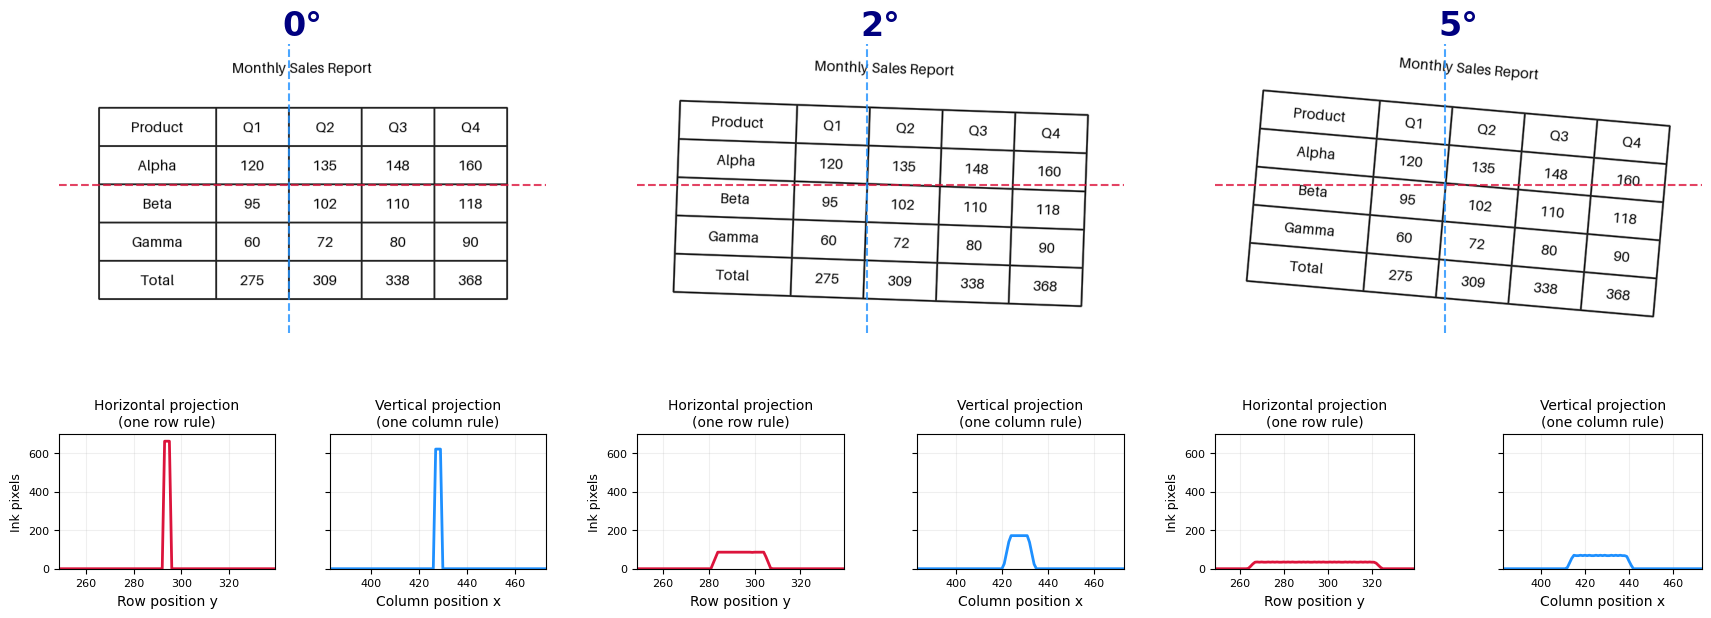

In [2]:
angles = (0, 2, 5)
fig = plt.figure(figsize=(17, 6.3), layout="constrained")
subfigs = fig.subfigures(1, 3, wspace=0.06)

for subfig, angle in zip(subfigs, angles):
    grid = subfig.add_gridspec(2, 2, height_ratios=[3, 1])
    image_ax = subfig.add_subplot(grid[0, :])
    red_ax = subfig.add_subplot(grid[1, 0])
    blue_ax = subfig.add_subplot(grid[1, 1])

    # PIL rotates counterclockwise; negative angle gives the clockwise tilt shown here.
    rotated = page.rotate(-angle, resample=Image.Resampling.BICUBIC, fillcolor=255)
    h_rotated = h_rule.rotate(-angle, resample=Image.Resampling.NEAREST, fillcolor=0)
    v_rotated = v_rule.rotate(-angle, resample=Image.Resampling.NEAREST, fillcolor=0)
    h_profile = (np.asarray(h_rotated) > 0).sum(axis=1)
    v_profile = (np.asarray(v_rotated) > 0).sum(axis=0)

    image_ax.imshow(rotated, cmap="gray", vmin=0, vmax=255)
    image_ax.axhline(Y_REF, color="crimson", linestyle="--", linewidth=1.5, alpha=0.8)
    image_ax.axvline(X_REF, color="dodgerblue", linestyle="--", linewidth=1.5, alpha=0.8)
    image_ax.set_xlim(55, 845)
    image_ax.set_ylim(535, 65)
    image_ax.axis("off")
    image_ax.set_title(f"{angle}°", fontsize=24, color="navy", weight="bold")

    red_ax.plot(np.arange(H), h_profile, color="crimson", linewidth=2)
    red_ax.set_xlim(Y_REF - 45, Y_REF + 45)
    red_ax.set_ylim(0, 700)
    red_ax.set_title("Horizontal projection\n(one row rule)", fontsize=10)
    red_ax.set_xlabel("Row position y")
    red_ax.set_ylabel("Ink pixels", fontsize=9)

    blue_ax.plot(np.arange(W), v_profile, color="dodgerblue", linewidth=2)
    blue_ax.set_xlim(X_REF - 45, X_REF + 45)
    blue_ax.set_ylim(0, 350)
    blue_ax.set_title("Vertical projection\n(one column rule)", fontsize=10)
    blue_ax.set_xlabel("Column position x")
    blue_ax.tick_params(labelleft=False)
    for ax in (red_ax, blue_ax):
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=8)

plt.show()

**Cách đọc:** tại 0°, đường ngang nằm gần một hàng pixel và đường dọc nằm gần một cột pixel nên hai đỉnh hẹp. Khi xoay, mỗi đường đi qua nhiều hàng/cột hơn: response trải rộng và đỉnh thấp đi. Trên ảnh, đường đứt nét là **trục tham chiếu cố định**, còn hai profile được tính từ các đường kẻ sau khi xoay. Đồ thị chỉ dùng một đường được chọn; chiếu toàn bộ bảng sẽ tạo nhiều đỉnh.

## Sobel X and Y on a real training page

The crop below comes from `training_set/images/train-00460_p01.jpg`, near a table-rule intersection. The page is an M2 training sample. `Gx` responds most strongly to left-right intensity changes (vertical edges); `Gy` responds to top-bottom changes (horizontal edges). Responses also contain text and JPEG artifacts because this is a real image crop.

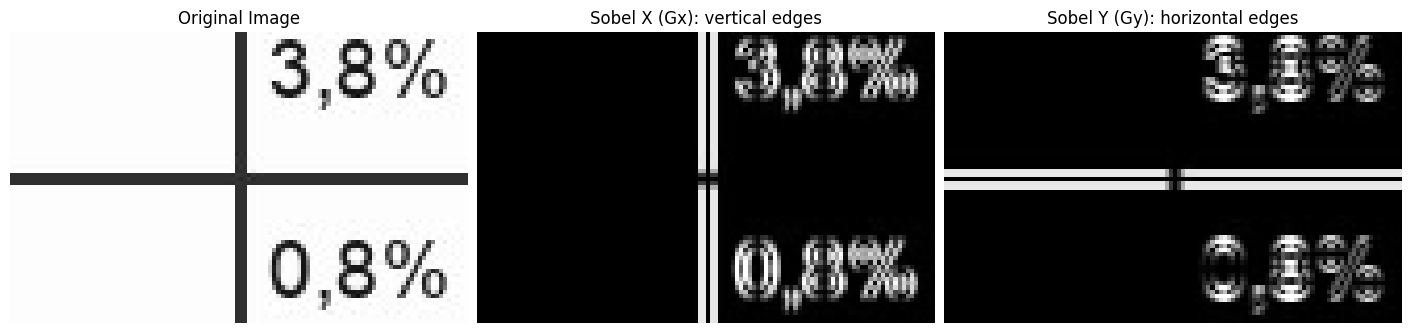

In [4]:
from pathlib import Path
from scipy.signal import correlate2d

relative_image = Path("data/training_set/images/train-00460_p01.jpg")
image_path = next(
    (root / relative_image for root in (Path.cwd(), Path.cwd().parent, Path.cwd() / "Doc2Table")
     if (root / relative_image).is_file()),
    None,
)
if image_path is None:
    raise FileNotFoundError(f"Place the training data under Doc2Table/data: {relative_image}")

page_gray = Image.open(image_path).convert("L")
cx, cy = 818, 846  # Visible crossing of two table rules in the original 1800 x 2546 page.
patch = np.asarray(page_gray.crop((cx - 55, cy - 35, cx + 55, cy + 35)), dtype=np.float32)
kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
gx = correlate2d(patch, kx, mode="same", boundary="symm")
gy = correlate2d(patch, ky, mode="same", boundary="symm")
assert patch.shape == gx.shape == gy.shape == (70, 110)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
scale = max(np.percentile(np.abs(gx), 99.5), np.percentile(np.abs(gy), 99.5))

axes[0].imshow(patch, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")

for ax, response, title in zip(
    axes[1:], (gx, gy),
    ("Sobel X (Gx): vertical edges", "Sobel Y (Gy): horizontal edges"),
):
    ax.imshow(np.abs(response), cmap="gray", vmin=0, vmax=scale)
    ax.set_title(title)

for ax in axes:
    ax.axis("off")
plt.show()

## Canny edge detection: five stages on a real page

This uses the same M2 page (`train-00460_p01.jpg`). The five panels show Gaussian smoothing, gradient magnitude, non-maximum suppression (NMS), double-threshold classes, and hysteresis. Red = strong, yellow = weak, black = rejected. Thresholds are chosen for this visualization; the baseline notebook calls OpenCV `Canny` directly with its own thresholds.

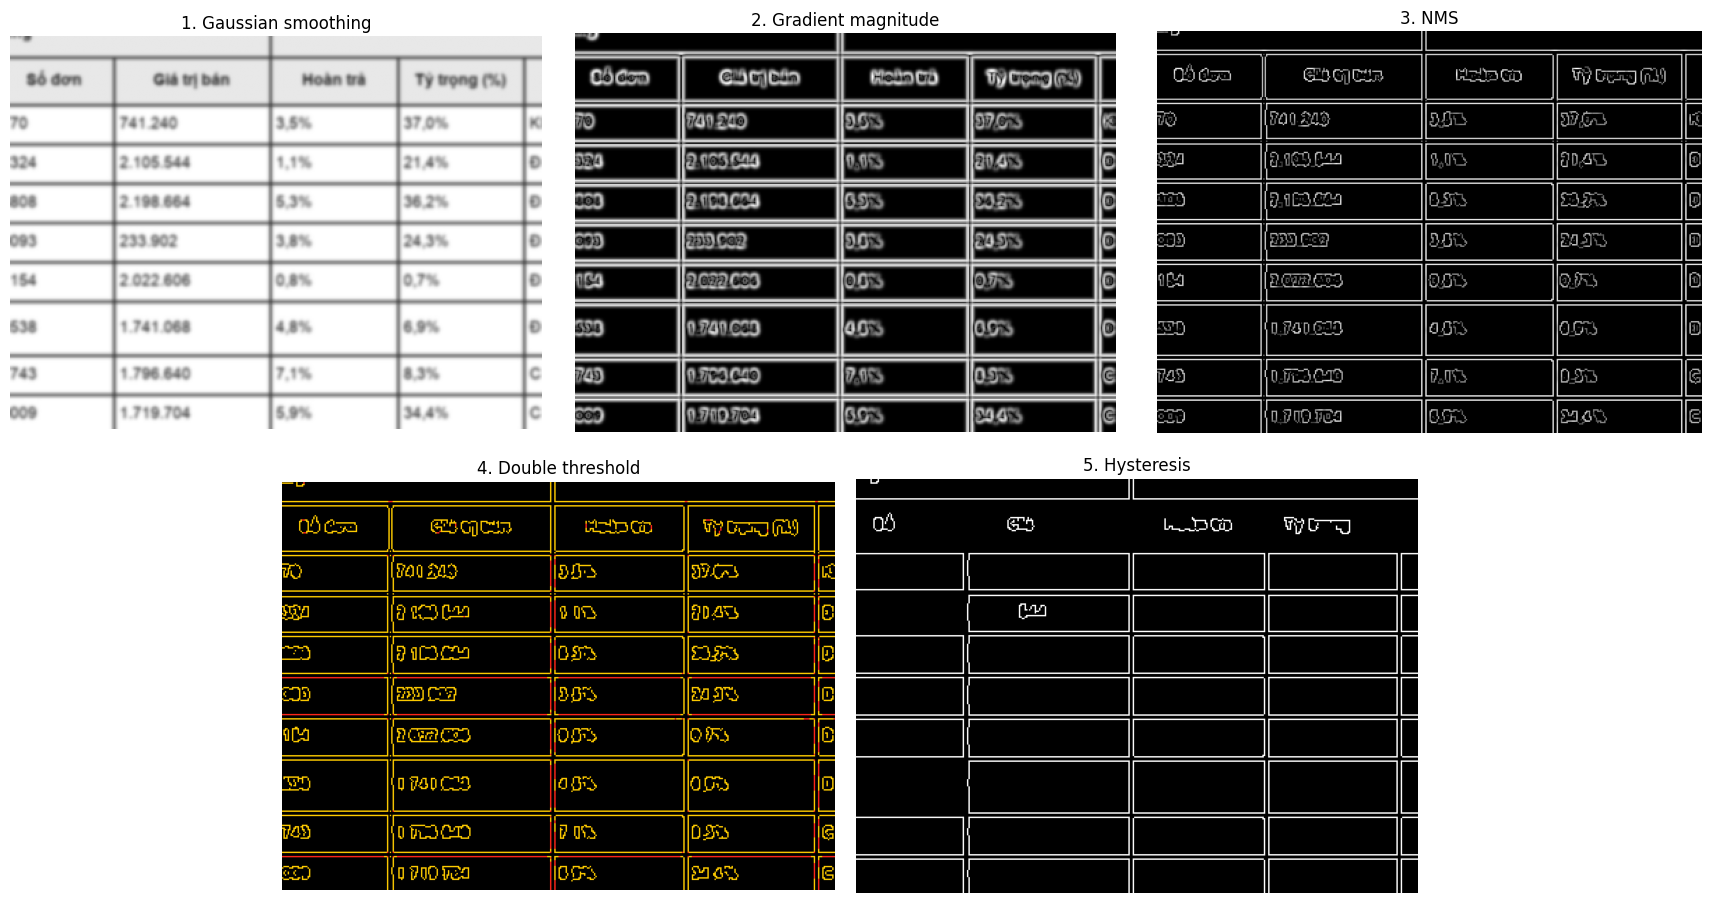

In [6]:
from scipy.ndimage import gaussian_filter, sobel, map_coordinates, binary_propagation

# A larger table region from the same real training page used above.
region = page_gray.crop((500, 570, 1150, 1050))
region.thumbnail((390, 290), Image.Resampling.LANCZOS)
original = np.asarray(region, dtype=np.float32)
smoothed = gaussian_filter(original, sigma=1.2)

grad_x = sobel(smoothed, axis=1)
grad_y = sobel(smoothed, axis=0)
magnitude = np.hypot(grad_x, grad_y)

# Compare each pixel with its two neighbors along the local gradient direction.
yy, xx = np.indices(magnitude.shape)
unit_x = grad_x / np.maximum(magnitude, 1e-6)
unit_y = grad_y / np.maximum(magnitude, 1e-6)
forward = map_coordinates(magnitude, [yy + unit_y, xx + unit_x], order=1, mode="nearest")
backward = map_coordinates(magnitude, [yy - unit_y, xx - unit_x], order=1, mode="nearest")
nms = np.where((magnitude >= forward) & (magnitude >= backward), magnitude, 0)

positive = nms[nms > 0]
high = np.percentile(positive, 88)
low = 0.4 * high
strong = nms >= high
weak = (nms >= low) & ~strong
edges = binary_propagation(strong, mask=strong | weak, structure=np.ones((3, 3)))

classes = np.zeros((*nms.shape, 3), dtype=np.float32)
classes[weak] = (1.0, 0.8, 0.0)     # yellow: weak
classes[strong] = (1.0, 0.15, 0.1) # red: strong

fig = plt.figure(figsize=(17, 9), layout="constrained")
grid = fig.add_gridspec(2, 6)
axes = [
    fig.add_subplot(grid[0, 0:2]),
    fig.add_subplot(grid[0, 2:4]),
    fig.add_subplot(grid[0, 4:6]),
    fig.add_subplot(grid[1, 1:3]),
    fig.add_subplot(grid[1, 3:5]),
]
images = (smoothed, magnitude, nms, classes, edges)
titles = ("1. Gaussian smoothing", "2. Gradient magnitude", "3. NMS",
          "4. Double threshold", "5. Hysteresis")
for ax, image, title in zip(axes, images, titles):
    if title.startswith("4."):
        ax.imshow(image)
    elif title.startswith("5."):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(image, cmap="gray", vmin=0)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
plt.show()

## From edge pixels to straight lines (real sample)

This section uses the **final edge map after hysteresis** from the five-stage Canny example above. `HoughLinesP` groups those pixels into line segments. The middle panel colors actual surviving edge pixels close to one detected horizontal segment (orange) and one vertical segment (cyan). The right panel overlays detected near-horizontal and near-vertical segments on the real crop. A dark rule often yields two nearby edge contours, so paired Hough segments are expected.

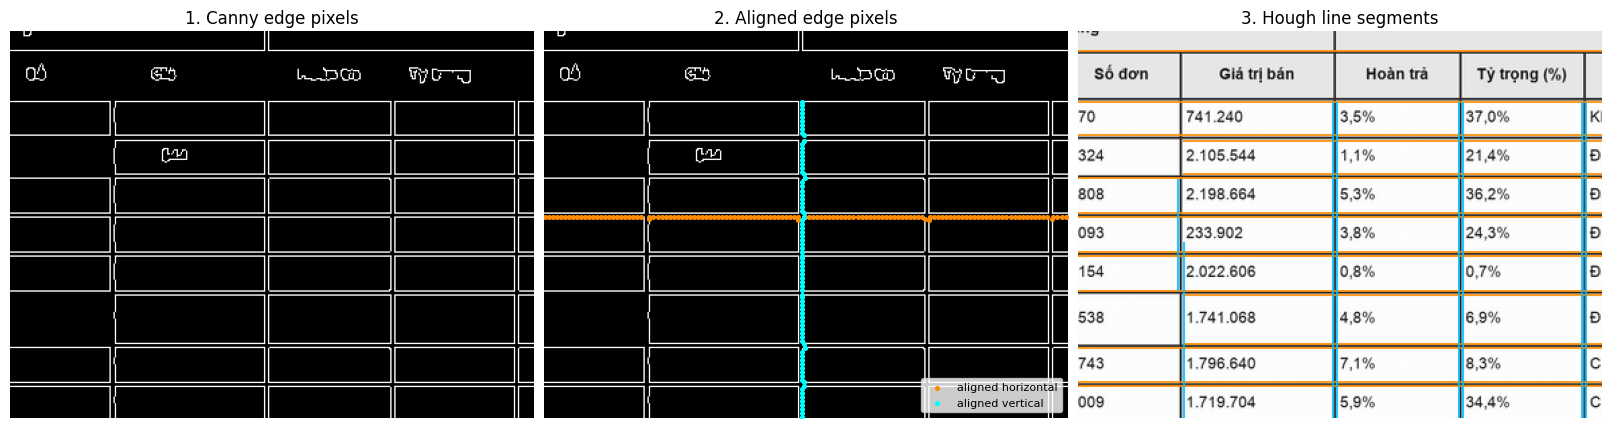

In [9]:
import cv2

source = original.astype(np.uint8)
edge_map = edges.astype(np.uint8) * 255
raw_lines = cv2.HoughLinesP(
    edge_map, rho=1, theta=np.pi / 1800, threshold=45,
    minLineLength=80, maxLineGap=12,
)
if raw_lines is None:
    raise RuntimeError("No Hough lines found after hysteresis")
segments = raw_lines.reshape(-1, 4)
near_horizontal = [s for s in segments if abs(s[3] - s[1]) <= 0.09 * abs(s[2] - s[0])]
near_vertical = [s for s in segments if abs(s[2] - s[0]) <= 0.09 * abs(s[3] - s[1])]
if not near_horizontal or not near_vertical:
    raise RuntimeError("Expected both horizontal and vertical table rules")

# Pick one long segment in each direction and show only Canny pixels on them.
selected_h = max(near_horizontal, key=lambda s: abs(s[2] - s[0]))
selected_v = max(near_vertical, key=lambda s: abs(s[3] - s[1]))
h_mask = np.zeros_like(edge_map)
v_mask = np.zeros_like(edge_map)
for mask, segment in ((h_mask, selected_h), (v_mask, selected_v)):
    x0, y0, x1, y1 = map(int, segment)
    cv2.line(mask, (x0, y0), (x1, y1), color=255, thickness=3)
h_y, h_x = np.nonzero((edge_map > 0) & (h_mask > 0))
v_y, v_x = np.nonzero((edge_map > 0) & (v_mask > 0))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")
axes[0].imshow(edge_map, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("1. Canny edge pixels")
axes[1].imshow(edge_map, cmap="gray", vmin=0, vmax=255)
axes[1].scatter(h_x[::3], h_y[::3], s=7, color="darkorange", label="aligned horizontal")
axes[1].scatter(v_x[::3], v_y[::3], s=7, color="cyan", label="aligned vertical")
axes[1].set_title("2. Aligned edge pixels")
axes[1].legend(loc="lower right", fontsize=8)
axes[2].imshow(source, cmap="gray", vmin=0, vmax=255)
for group, color in ((near_horizontal, "darkorange"), (near_vertical, "deepskyblue")):
    for x0, y0, x1, y1 in group:
        axes[2].plot((x0, x1), (y0, y1), color=color, linewidth=1.5, alpha=0.85)
axes[2].set_title("3. Hough line segments")
for ax in axes:
    ax.axis("off")
plt.show()

## Estimate skew and rotate: three images in one row

A crop from `train-00460_p01.jpg` is rotated clockwise by 2 degrees for this demonstration. The three images show: (1) its Canny edge map, (2) Hough segments over the tilted crop with near-horizontal lines kept in green and rejected lines in red, and (3) the corrected crop. The median angle of kept lines controls the correction. The private-test prediction path in `baseline_TACVU2_improve_1_colab.ipynb` does not call deskew.

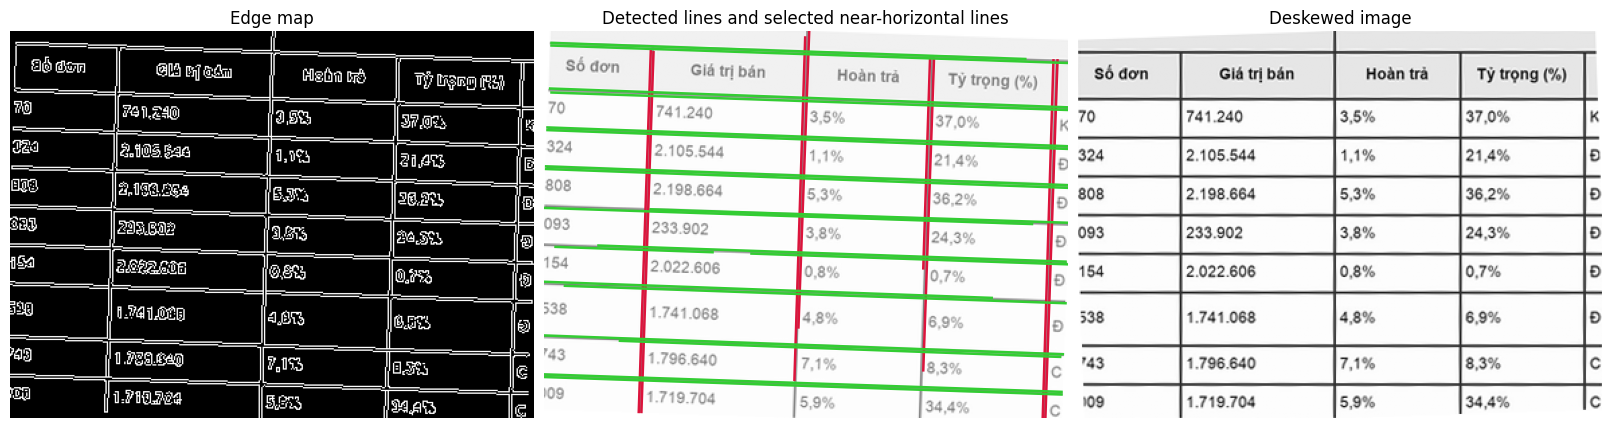

In [9]:
# Tilt the real training crop by 2 degrees to make deskew visible.
source = original.astype(np.uint8)
height, width = source.shape
center = (width / 2, height / 2)
tilt_matrix = cv2.getRotationMatrix2D(center, -2.0, 1.0)
tilted = cv2.warpAffine(source, tilt_matrix, (width, height),
                        flags=cv2.INTER_CUBIC, borderValue=255)
tilted_edges = cv2.Canny(tilted, 60, 180)
raw_segments = cv2.HoughLinesP(
    tilted_edges, rho=1, theta=np.pi / 1800, threshold=45,
    minLineLength=80, maxLineGap=12,
)
if raw_segments is None:
    raise RuntimeError("No Hough segments found in the tilted crop")

kept, rejected, angles = [], [], []
for segment in raw_segments.reshape(-1, 4):
    x0, y0, x1, y1 = map(int, segment)
    angle = np.degrees(np.arctan2(y1 - y0, x1 - x0))
    angle = (angle + 90) % 180 - 90
    if abs(angle) <= 4:
        kept.append((x0, y0, x1, y1))
        angles.append(angle)
    else:
        rejected.append((x0, y0, x1, y1))
if not angles:
    raise RuntimeError("No near-horizontal segments found")
estimated_skew = float(np.median(angles))
corrected = cv2.warpAffine(
    tilted, cv2.getRotationMatrix2D(center, estimated_skew, 1.0),
    (width, height), flags=cv2.INTER_CUBIC, borderValue=255,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), layout="constrained")

axes[0].imshow(tilted_edges, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Edge map")

axes[1].imshow(tilted, cmap="gray", vmin=0, vmax=255, alpha=0.55)
for group, color in ((rejected, "crimson"), (kept, "limegreen")):
    for x0, y0, x1, y1 in group:
        axes[1].plot((x0, x1), (y0, y1), color=color, linewidth=1.8)
axes[1].set_title("Detected lines and selected near-horizontal lines")

axes[2].imshow(corrected, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Deskewed image")
for ax in axes:
    ax.axis("off")
plt.show()